# Breeding outcomes analysis — Sunshine BirdWorld (demonstration)

> ## Experimental Demonstration Repository
>
> This is an early stage, nonproduction demonstration of proposed research methods, schemas, synthetic data and analysis workflows. It does not contain validated Sunshine BirdWorld research findings unless expressly stated. Sunshine BirdWorld’s substantive scientific work is ordinarily communicated through peer reviewed journals, veterinary and avicultural publications, books, conferences and established scientific forums. The material must not be used for veterinary, clinical, husbandry, conservation, legal or regulatory decisions without independent expert review. Sensitive operational information is intentionally excluded.

> **SYNTHETIC DATA WARNING**
>
> The dataset analysed in this notebook (`example_breeding_events.csv`) is **entirely synthetic**.
> It exists only to demonstrate schemas, validation, and reproducible analysis workflows.
>
> **Do not** present these numbers as Sunshine BirdWorld institutional breeding results,
> conservation performance, or clinical outcomes.

**Contact:** [info@sunshinebirdworld.org](mailto:info@sunshinebirdworld.org) · [https://www.sunshinebirdworld.org](https://www.sunshinebirdworld.org)  
**Principal investigators:** Drs Debashis & Anindita Banerjee

**Metric definitions:** [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md) §13  
**Validation rules:** [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md) §6


## 0. Setup

Import libraries, resolve the data path from either `notebooks/` or the repository root, and ensure `../src` is on `sys.path` so `avian_metrics` can be imported.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve repository root whether the kernel cwd is notebooks/ or the repo root
_cwd = Path.cwd().resolve()
if (_cwd / "data" / "example_breeding_events.csv").exists():
    REPO_ROOT = _cwd
elif (_cwd.parent / "data" / "example_breeding_events.csv").exists():
    REPO_ROOT = _cwd.parent
elif (_cwd / ".." / "data" / "example_breeding_events.csv").resolve().exists():
    REPO_ROOT = (_cwd / "..").resolve()
else:
    raise FileNotFoundError(
        "Could not locate data/example_breeding_events.csv from "
        f"{_cwd}. Run from notebooks/ or the repository root."
    )

DATA_PATH = REPO_ROOT / "data" / "example_breeding_events.csv"
OUTPUT_DIR = REPO_ROOT / "outputs"
SRC_DIR = REPO_ROOT / "src"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import avian_metrics as am

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("SYNTHETIC DATA — not institutional results")
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_PATH = {DATA_PATH}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"avian_metrics loaded from: {am.__file__}")

SYNTHETIC DATA — not institutional results
REPO_ROOT = /Users/anindita/Music/Sunshine BirdWorld
DATA_PATH = /Users/anindita/Music/Sunshine BirdWorld/data/example_breeding_events.csv
OUTPUT_DIR = /Users/anindita/Music/Sunshine BirdWorld/outputs
avian_metrics loaded from: /Users/anindita/Music/Sunshine BirdWorld/src/avian_metrics.py


## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} egg records (synthetic).")
print(f"Columns ({df.shape[1]}): {list(df.columns)}")
df.head()

Loaded 160 egg records (synthetic).
Columns (19): ['egg_id', 'clutch_id', 'pair_id', 'species_scientific', 'species_common', 'lay_date', 'season', 'incubation_method', 'initial_weight_g', 'fertility_status', 'embryo_loss_stage', 'hatch_status', 'hatch_date', 'hatch_assistance', 'chick_id', 'chick_status_day7', 'data_quality_flag', 'source_record_type', 'verified_status']


,egg_id,clutch_id,pair_id,species_scientific,species_common,lay_date,season,incubation_method,initial_weight_g,fertility_status,embryo_loss_stage,hatch_status,hatch_date,hatch_assistance,chick_id,chick_status_day7,data_quality_flag,source_record_type,verified_status
0,EGG-0001,CL-01-001,PAIR-01-01,Ara chloropterus,Green-winged Macaw,2024-01-07,cool-dry,mixed,27.5000,fertile,none,hatched,2024-02-06,none,CHK-01-0001,alive,ok,combined,single_checked
1,EGG-0002,CL-01-001,PAIR-01-01,Ara chloropterus,Green-winged Macaw,2024-01-08,cool-dry,parental,24.1000,fertile,none,hatched,2024-02-01,none,CHK-01-0002,alive,ok,combined,single_checked
2,EGG-0003,CL-01-001,PAIR-01-01,Ara chloropterus,Green-winged Macaw,2024-01-12,cool-dry,parental,25.2000,fertile,none,hatched,2024-02-07,none,CHK-01-0003,alive,ok,combined,single_checked
3,EGG-0004,CL-01-001,PAIR-01-01,Ara chloropterus,Green-winged Macaw,2024-01-14,cool-dry,artificial,28.2000,infertile,not_applicable,not_hatched,NaN,not_applicable,NaN,not_applicable,ok,spreadsheet,double_checked
4,EGG-0005,CL-01-002,PAIR-01-01,Ara chloropterus,Green-winged Macaw,2024-01-18,cool-dry,mixed,26.0000,fertile,none,hatched,2024-02-15,none,CHK-01-0005,alive,ok,spreadsheet,double_checked


In [3]:
print("Species counts:")
display(df["species_scientific"].value_counts().rename("n").to_frame())
print("Season counts:")
display(df["season"].value_counts().rename("n").to_frame())
print("Fertility / hatch / day-7 / quality:")
display(df["fertility_status"].value_counts().rename("n").to_frame())
display(df["hatch_status"].value_counts().rename("n").to_frame())
display(df["chick_status_day7"].value_counts().rename("n").to_frame())
display(df["data_quality_flag"].value_counts().rename("n").to_frame())

Species counts:


,n
species_scientific,
Ara chloropterus,40
Cacatua moluccensis,40
Probosciger aterrimus,40
Eclectus roratus,40


Season counts:


,n
season,
cool-dry,59
hot-humid,51
transition,50


Fertility / hatch / day-7 / quality:


,n
fertility_status,
fertile,119
infertile,41


,n
hatch_status,
hatched,81
not_hatched,79


,n
chick_status_day7,
not_applicable,79
alive,75
died,6


,n
data_quality_flag,
ok,160


## 2. Data quality checks

Schema validation, duplicate detection, the nine logical rules from the data dictionary, and missingness.

In [4]:
schema = am.validate_egg_schema(df)
print("Schema validation:", "PASS" if schema["ok"] else "FAIL")
print(schema["extra_info"])
print(f"Rows={schema['n_rows']}, columns={schema['n_columns']}")
if schema["missing_columns"]:
    print("Missing:", schema["missing_columns"])

Schema validation: PASS
Schema valid: all required egg columns present.
Rows=160, columns=19


In [5]:
dup = am.duplicate_report(df, id_col="egg_id")
print("Duplicate report:", "PASS" if dup["ok"] else "FAIL")
print(dup["message"])
print(f"n_rows={dup['n_rows']}, n_unique={dup['n_unique']}, "
      f"n_duplicate_rows={dup['n_duplicate_rows']}")

Duplicate report: PASS
No duplicate egg_id values.
n_rows=160, n_unique=160, n_duplicate_rows=0


In [6]:
logic = am.check_logical_rules(df)
logic_out = logic.copy()
logic_out["violating_egg_ids"] = logic_out["violating_egg_ids"].apply(
    lambda xs: ", ".join(xs[:10]) + ("…" if len(xs) > 10 else "")
)
logic_path = OUTPUT_DIR / "logical_validation_rules.csv"
logic.to_csv(logic_path, index=False)
print(f"Wrote {logic_path}")
print(f"Rules passed: {int(logic['passed'].sum())} / {len(logic)}")
display(logic_out)

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/logical_validation_rules.csv
Rules passed: 9 / 9


,rule_id,description,n_violations,violating_egg_ids,passed
0,1,egg_id must be unique,0,,True
1,2,hatch_status=hatched requires fertility_status=fertile,0,,True
2,3,hatch_status=hatched requires a hatch_date,0,,True
3,4,hatch_date cannot precede lay_date,0,,True
4,5,chick_status_day7 is applicable only to hatched eggs,0,,True
5,6,embryo_loss_stage is not_applicable for infertile eggs,0,,True
6,7,fertile non-hatched egg should have loss stage or unknown,0,,True
7,8,initial_weight_g must be positive when present (species limits external),0,,True
8,9,exclusion_reason required when data_quality_flag=exclude,0,,True


In [7]:
miss = am.missingness_report(df)
miss_path = OUTPUT_DIR / "missingness_report.csv"
miss.to_csv(miss_path, index=False)
print(f"Wrote {miss_path}")
display(miss)

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/missingness_report.csv


,column,n_missing,n_present,missing_rate
0,chick_id,79,81,0.4938
1,hatch_date,79,81,0.4938
2,egg_id,0,160,0.0000
3,embryo_loss_stage,0,160,0.0000
4,source_record_type,0,160,0.0000
5,data_quality_flag,0,160,0.0000
6,chick_status_day7,0,160,0.0000
7,hatch_assistance,0,160,0.0000
8,hatch_status,0,160,0.0000
9,fertility_status,0,160,0.0000


## 3. Core derived metrics (overall)

Per DATA_DICTIONARY §13:

- **Fertility rate** = \(F / N_A\) (assessable fertility only)
- **Overall hatch rate** = \(H / N\)
- **Hatchability of fertile eggs** = \(H / F\)
- **Day-7 survival** = \(S_7 / (S_7 + D_7)\)

Wilson 95% confidence intervals accompany every rate. Numerators and denominators are always shown.

In [8]:
core = am.core_metrics_summary(df, quality_ok_only=False)
core_path = OUTPUT_DIR / "core_metrics_overall.csv"
core.to_csv(core_path, index=False)
print("SYNTHETIC DATA — core metrics (all records)")
print(f"Wrote {core_path}")
display(core)

for _, row in core.iterrows():
    print(
        f"{row['metric']}: {row['successes']}/{row['n']} = {row['rate']:.3f} "
        f"(95% Wilson CI {row['ci_low']:.3f}–{row['ci_high']:.3f})"
    )

SYNTHETIC DATA — core metrics (all records)
Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/core_metrics_overall.csv


,metric,n,successes,rate,ci_low,ci_high
0,fertility_rate,160.0000,119.0000,0.7438,0.6709,0.8051
1,overall_hatch_rate,160.0000,81.0000,0.5062,0.4295,0.5827
2,hatchability_of_fertile,119.0000,81.0000,0.6807,0.5924,0.7577
3,day7_survival,81.0000,75.0000,0.9259,0.8477,0.9656


fertility_rate: 119.0/160.0 = 0.744 (95% Wilson CI 0.671–0.805)
overall_hatch_rate: 81.0/160.0 = 0.506 (95% Wilson CI 0.430–0.583)
hatchability_of_fertile: 81.0/119.0 = 0.681 (95% Wilson CI 0.592–0.758)
day7_survival: 75.0/81.0 = 0.926 (95% Wilson CI 0.848–0.966)


## 4. Species-stratified analysis

In [9]:
species_fert = am.stratified_proportion(df, "species_scientific", am.fertility_rate)
species_fert.insert(0, "metric", "fertility_rate")
species_hatch = am.stratified_proportion(df, "species_scientific", am.overall_hatch_rate)
species_hatch.insert(0, "metric", "overall_hatch_rate")
species_hab = am.stratified_proportion(df, "species_scientific", am.hatchability_of_fertile)
species_hab.insert(0, "metric", "hatchability_of_fertile")
species_d7 = am.stratified_proportion(df, "species_scientific", am.day7_survival)
species_d7.insert(0, "metric", "day7_survival")

species_metrics = pd.concat(
    [species_fert, species_hatch, species_hab, species_d7], ignore_index=True
)
species_path = OUTPUT_DIR / "metrics_by_species.csv"
species_metrics.to_csv(species_path, index=False)
print(f"Wrote {species_path}")
display(species_metrics)

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/metrics_by_species.csv


,metric,species_scientific,n,successes,rate,ci_low,ci_high
0,fertility_rate,Ara chloropterus,40.0000,31.0000,0.7750,0.6250,0.8768
1,fertility_rate,Cacatua moluccensis,40.0000,29.0000,0.7250,0.5717,0.8389
2,fertility_rate,Eclectus roratus,40.0000,33.0000,0.8250,0.6805,0.9125
3,fertility_rate,Probosciger aterrimus,40.0000,26.0000,0.6500,0.4951,0.7787
4,overall_hatch_rate,Ara chloropterus,40.0000,20.0000,0.5000,0.3520,0.6480
5,overall_hatch_rate,Cacatua moluccensis,40.0000,20.0000,0.5000,0.3520,0.6480
6,overall_hatch_rate,Eclectus roratus,40.0000,25.0000,0.6250,0.4703,0.7578
7,overall_hatch_rate,Probosciger aterrimus,40.0000,16.0000,0.4000,0.2635,0.5540
8,hatchability_of_fertile,Ara chloropterus,31.0000,20.0000,0.6452,0.4695,0.7888
9,hatchability_of_fertile,Cacatua moluccensis,29.0000,20.0000,0.6897,0.5077,0.8272


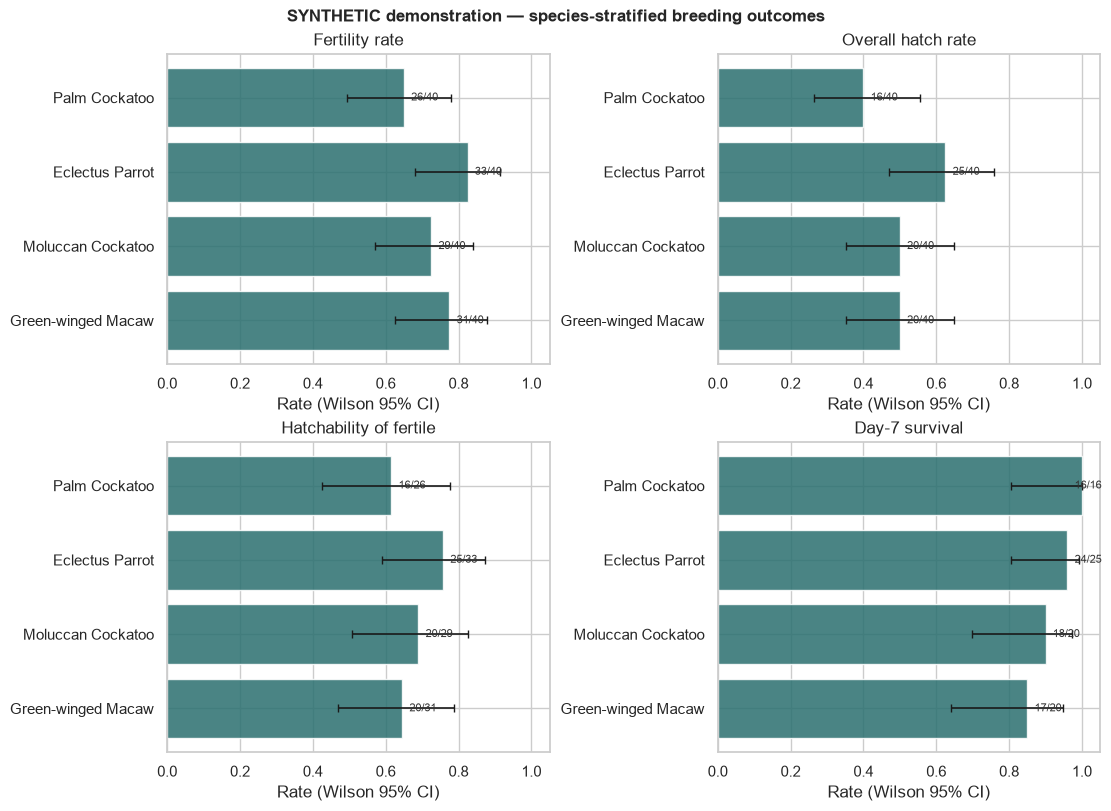

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/species_stratified_rates.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
metric_order = [
    ("fertility_rate", "Fertility rate"),
    ("overall_hatch_rate", "Overall hatch rate"),
    ("hatchability_of_fertile", "Hatchability of fertile"),
    ("day7_survival", "Day-7 survival"),
]
for ax, (metric_key, title) in zip(axes.ravel(), metric_order):
    sub = species_metrics[species_metrics["metric"] == metric_key].copy()
    # Short common names for labels
    label_map = (
        df.groupby("species_scientific")["species_common"].first().to_dict()
    )
    sub["label"] = sub["species_scientific"].map(label_map)
    ax.barh(sub["label"], sub["rate"], color="#2a6f6f", alpha=0.85)
    ax.errorbar(
        sub["rate"],
        sub["label"],
        xerr=[sub["rate"] - sub["ci_low"], sub["ci_high"] - sub["rate"]],
        fmt="none",
        ecolor="#1a1a1a",
        capsize=3,
        linewidth=1.2,
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Rate (Wilson 95% CI)")
    ax.set_title(title)
    for i, r in sub.iterrows():
        ax.text(
            min(r["rate"] + 0.02, 0.98),
            r["label"],
            f"{int(r['successes'])}/{int(r['n'])}",
            va="center",
            fontsize=8,
            color="#333333",
        )

fig.suptitle(
    "SYNTHETIC demonstration — species-stratified breeding outcomes",
    fontsize=12,
    fontweight="bold",
)
fig_path = OUTPUT_DIR / "species_stratified_rates.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")

## 5. Season-stratified analysis

In [11]:
season_fert = am.stratified_proportion(df, "season", am.fertility_rate)
season_fert.insert(0, "metric", "fertility_rate")
season_hatch = am.stratified_proportion(df, "season", am.overall_hatch_rate)
season_hatch.insert(0, "metric", "overall_hatch_rate")
season_hab = am.stratified_proportion(df, "season", am.hatchability_of_fertile)
season_hab.insert(0, "metric", "hatchability_of_fertile")
season_d7 = am.stratified_proportion(df, "season", am.day7_survival)
season_d7.insert(0, "metric", "day7_survival")

season_metrics = pd.concat(
    [season_fert, season_hatch, season_hab, season_d7], ignore_index=True
)
season_path = OUTPUT_DIR / "metrics_by_season.csv"
season_metrics.to_csv(season_path, index=False)
print(f"Wrote {season_path}")
display(season_metrics)

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/metrics_by_season.csv


,metric,season,n,successes,rate,ci_low,ci_high
0,fertility_rate,cool-dry,59.0000,46.0000,0.7797,0.6587,0.8665
1,fertility_rate,hot-humid,51.0000,36.0000,0.7059,0.5700,0.8129
2,fertility_rate,transition,50.0000,37.0000,0.7400,0.6045,0.8413
3,overall_hatch_rate,cool-dry,59.0000,31.0000,0.5254,0.4004,0.6473
4,overall_hatch_rate,hot-humid,51.0000,23.0000,0.4510,0.3227,0.5862
5,overall_hatch_rate,transition,50.0000,27.0000,0.5400,0.4040,0.6703
6,hatchability_of_fertile,cool-dry,46.0000,31.0000,0.6739,0.5297,0.7913
7,hatchability_of_fertile,hot-humid,36.0000,23.0000,0.6389,0.4758,0.7752
8,hatchability_of_fertile,transition,37.0000,27.0000,0.7297,0.5702,0.8460
9,day7_survival,cool-dry,31.0000,30.0000,0.9677,0.8381,0.9943


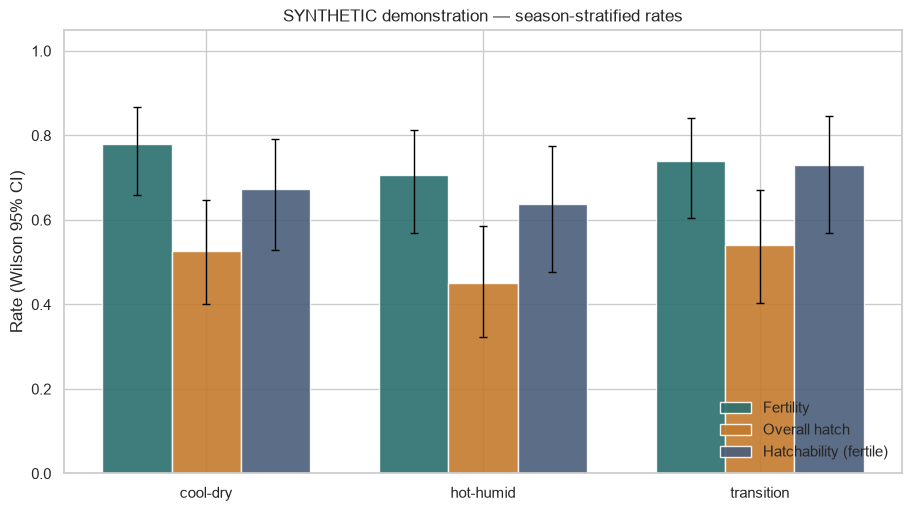

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/season_stratified_rates.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
plot_df = season_metrics[season_metrics["metric"].isin(
    ["fertility_rate", "overall_hatch_rate", "hatchability_of_fertile"]
)].copy()
metric_labels = {
    "fertility_rate": "Fertility",
    "overall_hatch_rate": "Overall hatch",
    "hatchability_of_fertile": "Hatchability (fertile)",
}
plot_df["metric_label"] = plot_df["metric"].map(metric_labels)
seasons = list(plot_df["season"].unique())
metrics_shown = list(metric_labels.values())
x = np.arange(len(seasons))
width = 0.25
palette = ["#2a6f6f", "#c47a2c", "#4a5d7a"]
for i, (mkey, mlabel) in enumerate(metric_labels.items()):
    sub = plot_df[plot_df["metric"] == mkey].set_index("season").reindex(seasons)
    ax.bar(
        x + (i - 1) * width,
        sub["rate"],
        width,
        label=mlabel,
        color=palette[i],
        alpha=0.9,
    )
    ax.errorbar(
        x + (i - 1) * width,
        sub["rate"],
        yerr=[sub["rate"] - sub["ci_low"], sub["ci_high"] - sub["rate"]],
        fmt="none",
        ecolor="black",
        capsize=3,
        linewidth=1,
    )
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate (Wilson 95% CI)")
ax.set_title("SYNTHETIC demonstration — season-stratified rates")
ax.legend(frameon=False, loc="lower right")
fig_path = OUTPUT_DIR / "season_stratified_rates.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")

## 6. Embryo-loss outcome analysis

Among fertile eggs that did not hatch, summarise embryo-loss stage distribution.

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/embryo_loss_summary.csv
Fertile, non-hatched eggs (N): 38


,embryo_loss_stage,n,proportion_of_fertile_unhatched,n_fertile_unhatched
0,late,16,0.4211,38
1,early,13,0.3421,38
2,middle,5,0.1316,38
3,unknown,4,0.1053,38


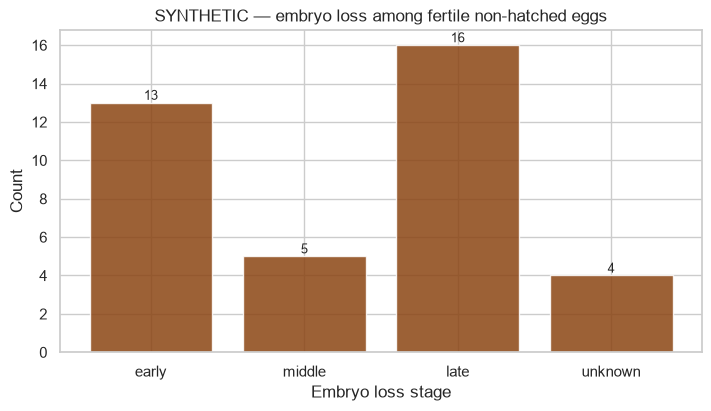

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/embryo_loss_stages.png


In [13]:
loss = am.embryo_loss_summary(df)
loss_path = OUTPUT_DIR / "embryo_loss_summary.csv"
loss.to_csv(loss_path, index=False)
print(f"Wrote {loss_path}")
print(f"Fertile, non-hatched eggs (N): {int(loss['n_fertile_unhatched'].iloc[0]) if len(loss) else 0}")
display(loss)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
order = ["early", "middle", "late", "unknown", "none", "not_applicable", "missing"]
loss_plot = loss.copy()
loss_plot["embryo_loss_stage"] = pd.Categorical(
    loss_plot["embryo_loss_stage"],
    categories=[c for c in order if c in set(loss_plot["embryo_loss_stage"])],
    ordered=True,
)
loss_plot = loss_plot.sort_values("embryo_loss_stage")
ax.bar(
    loss_plot["embryo_loss_stage"].astype(str),
    loss_plot["n"],
    color="#8b4513",
    alpha=0.85,
)
ax.set_ylabel("Count")
ax.set_xlabel("Embryo loss stage")
ax.set_title("SYNTHETIC — embryo loss among fertile non-hatched eggs")
for _, r in loss_plot.iterrows():
    ax.text(
        str(r["embryo_loss_stage"]),
        r["n"] + 0.15,
        f"{int(r['n'])}",
        ha="center",
        fontsize=9,
    )
fig_path = OUTPUT_DIR / "embryo_loss_stages.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")

## 7. Data-quality sensitivity analysis

Compare core metrics on **all** records versus records with `data_quality_flag == 'ok'` only.

In [14]:
core_all = am.core_metrics_summary(df, quality_ok_only=False)
core_all.insert(0, "subset", "all")
core_ok = am.core_metrics_summary(df, quality_ok_only=True)
core_ok.insert(0, "subset", "ok_only")
sensitivity = pd.concat([core_all, core_ok], ignore_index=True)
sens_path = OUTPUT_DIR / "data_quality_sensitivity.csv"
sensitivity.to_csv(sens_path, index=False)
print(f"Wrote {sens_path}")
display(sensitivity)

# Absolute rate differences (ok_only − all)
pivot = sensitivity.pivot(index="metric", columns="subset", values="rate")
if "ok_only" in pivot.columns and "all" in pivot.columns:
    pivot["delta_ok_minus_all"] = pivot["ok_only"] - pivot["all"]
display(pivot)

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/data_quality_sensitivity.csv


,subset,metric,n,successes,rate,ci_low,ci_high
0,all,fertility_rate,160.0000,119.0000,0.7438,0.6709,0.8051
1,all,overall_hatch_rate,160.0000,81.0000,0.5062,0.4295,0.5827
2,all,hatchability_of_fertile,119.0000,81.0000,0.6807,0.5924,0.7577
3,all,day7_survival,81.0000,75.0000,0.9259,0.8477,0.9656
4,ok_only,fertility_rate,160.0000,119.0000,0.7438,0.6709,0.8051
5,ok_only,overall_hatch_rate,160.0000,81.0000,0.5062,0.4295,0.5827
6,ok_only,hatchability_of_fertile,119.0000,81.0000,0.6807,0.5924,0.7577
7,ok_only,day7_survival,81.0000,75.0000,0.9259,0.8477,0.9656


subset,all,ok_only,delta_ok_minus_all
metric,,,
day7_survival,0.9259,0.9259,0.0000
fertility_rate,0.7438,0.7438,0.0000
hatchability_of_fertile,0.6807,0.6807,0.0000
overall_hatch_rate,0.5062,0.5062,0.0000


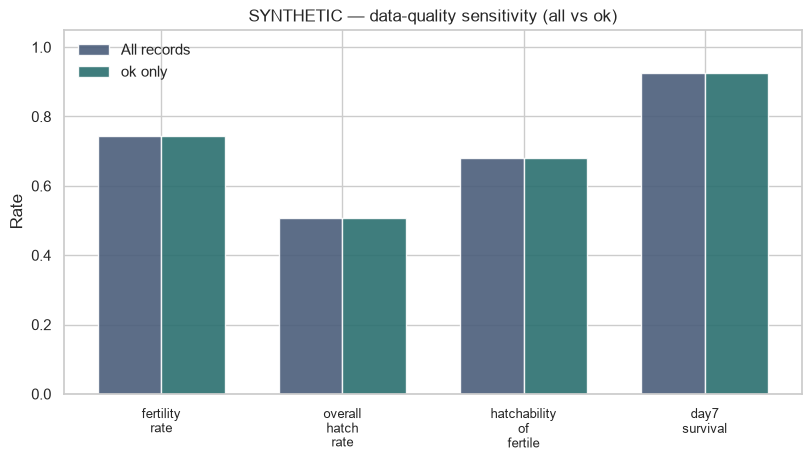

Wrote /Users/anindita/Music/Sunshine BirdWorld/outputs/data_quality_sensitivity.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
metrics = list(core_all["metric"])
x = np.arange(len(metrics))
width = 0.35
all_rates = core_all.set_index("metric").loc[metrics, "rate"]
ok_rates = core_ok.set_index("metric").loc[metrics, "rate"]
ax.bar(x - width / 2, all_rates, width, label="All records", color="#4a5d7a", alpha=0.9)
ax.bar(x + width / 2, ok_rates, width, label="ok only", color="#2a6f6f", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(
    [m.replace("_", "\n") for m in metrics],
    fontsize=9,
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rate")
ax.set_title("SYNTHETIC — data-quality sensitivity (all vs ok)")
ax.legend(frameon=False)
fig_path = OUTPUT_DIR / "data_quality_sensitivity.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")

## 8. Structured interpretation

### Observations (what the synthetic table shows)

1. Among assessable eggs, the fertility rate, overall hatch rate, hatchability among fertile eggs, and day-7 survival are reported above with numerators, denominators, and Wilson 95% CIs.
2. Species and season strata show absolute rate differences; some strata have small denominators, so interval width is informative.
3. Embryo-loss stages among fertile non-hatched eggs are dominated by late and early loss in this synthetic draw (see table/figure).
4. In this particular synthetic file, all rows have `data_quality_flag = ok`, so the sensitivity comparison of *ok* vs *all* is identical by construction — useful as a regression check for the pipeline.

### Inference boundaries (what we must not claim)

1. **These are not institutional results.** No causal claim about Sunshine BirdWorld husbandry, incubation practice, or species performance is warranted from this file.
2. Stratified contrasts are **descriptive**. Without a pre-registered contrast, multiplicity control, and real study design, differences between species or seasons are not confirmatory findings.
3. Wilson intervals quantify binomial sampling uncertainty under an independence assumption; they do not correct for clutch clustering, pair effects, or measurement error.
4. Synthetic generation may encode simplifying assumptions that real breeding systems violate (independence of eggs, stationary seasons, complete follow-up).

### Method note

All rates follow DATA_DICTIONARY §13. Fertility excludes `unknown` / `not_assessed` from \(N_A\). Day-7 survival uses only known `alive`/`died` outcomes. Contact for protocol questions: info@sunshinebirdworld.org.

## 9. Output inventory

In [16]:
outputs = sorted(OUTPUT_DIR.glob("*"))
print("Files in outputs/:")
for p in outputs:
    if p.name == ".gitkeep":
        continue
    print(f"  {p.name:40s}  {p.stat().st_size:8d} bytes")
print()
print("Done. Reminder: all numeric results above are from SYNTHETIC data.")

Files in outputs/:
  core_metrics_overall.csv                       361 bytes
  data_quality_sensitivity.csv                   738 bytes
  data_quality_sensitivity.png                 34056 bytes
  embryo_loss_stages.png                       31159 bytes
  embryo_loss_summary.csv                        200 bytes
  logical_validation_rules.csv                   617 bytes
  metrics_by_season.csv                         1159 bytes
  metrics_by_species.csv                        1539 bytes
  missingness_report.csv                         504 bytes
  season_stratified_rates.png                  43565 bytes
  species_stratified_rates.png                128017 bytes

Done. Reminder: all numeric results above are from SYNTHETIC data.
